# Superstore Sales Analysis with Machine Learning

This project analyzes Superstore sales data to understand sales performance across regions, categories, and time.  
It also applies machine learning techniques to classify shipping status and group orders based on sales and shipping behavior.

## Project Objectives

- Analyze overall sales performance.
- Identify top-performing regions and product categories.
- Explore yearly and monthly sales trends.
- Analyze shipping behavior.
- Apply Classification to predict shipping status.
- Apply Clustering to group similar orders.

## 1. Import Libraries

In this section, the required Python libraries are imported for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## 2. Load Dataset

The Superstore Sales dataset is loaded into a pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("Superstore Sales.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 3. Data Understanding

This section provides an initial overview of the dataset, including the number of rows and columns, data types, missing values, and duplicate records.

In [4]:
df.shape

(9800, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df.duplicated().sum()

0

## 4. Data Cleaning

In this section, the dataset is cleaned by removing unnecessary columns, checking missing values, removing duplicates, and standardizing column names.

In [9]:
df = df.drop(columns=["Row ID"])

In [10]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [11]:
df = df.drop_duplicates()

In [12]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='object')

In [13]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")

In [14]:
df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       9799 non-null   object 
 1   Order_Date     9799 non-null   object 
 2   Ship_Date      9799 non-null   object 
 3   Ship_Mode      9799 non-null   object 
 4   Customer_ID    9799 non-null   object 
 5   Customer_Name  9799 non-null   object 
 6   Segment        9799 non-null   object 
 7   Country        9799 non-null   object 
 8   City           9799 non-null   object 
 9   State          9799 non-null   object 
 10  Postal_Code    9788 non-null   float64
 11  Region         9799 non-null   object 
 12  Product_ID     9799 non-null   object 
 13  Category       9799 non-null   object 
 14  Sub_Category   9799 non-null   object 
 15  Product_Name   9799 non-null   object 
 16  Sales          9799 non-null   float64
dtypes: float64(2), object(15)
memory usage: 1.3+ MB


## 5. Feature Engineering

New features were created from existing columns to support deeper analysis.  
Date columns were converted into datetime format, and new columns such as order year, order month, and shipping days were created.

In [16]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)                                  

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       9799 non-null   object        
 1   Order_Date     9799 non-null   datetime64[ns]
 2   Ship_Date      9799 non-null   datetime64[ns]
 3   Ship_Mode      9799 non-null   object        
 4   Customer_ID    9799 non-null   object        
 5   Customer_Name  9799 non-null   object        
 6   Segment        9799 non-null   object        
 7   Country        9799 non-null   object        
 8   City           9799 non-null   object        
 9   State          9799 non-null   object        
 10  Postal_Code    9788 non-null   float64       
 11  Region         9799 non-null   object        
 12  Product_ID     9799 non-null   object        
 13  Category       9799 non-null   object        
 14  Sub_Category   9799 non-null   object        
 15  Product_Name   9799 non-nu

In [18]:
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Month_Name"] = df["Order_Date"].dt.month_name()
df["Shipping_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

In [19]:
df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,...,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Order_Year,Order_Month,Order_Month_Name,Shipping_Days
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,3
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,3
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,4
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,7
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,7


In [20]:
def shipping_status(days):
    if days <= 3:
        return"Fast Shipping"
    elif days <= 6:
        return"Normal Shipping"
    else:
        return"Late Shipping"
        
df["Shipping_Status"] = df["Shipping_Days"].apply(shipping_status)

In [21]:
df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Order_Year,Order_Month,Order_Month_Name,Shipping_Days,Shipping_Status
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,3,Fast Shipping
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,3,Fast Shipping
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,4,Normal Shipping
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,7,Late Shipping
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,7,Late Shipping


## 6. Key Performance Indicators (KPIs)

The main business KPIs are calculated to summarize the overall performance of the store.

In [22]:
total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
avg_sales = df["Sales"].mean()
total_customers = df["Customer_ID"].nunique()
total_products = df["Product_ID"].nunique()
avg_shipping_days = df["Shipping_Days"].mean()

print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Shipping Days:", round(avg_shipping_days, 2))
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Orders:", df["Order_ID"].nunique())
print("Average Sales:", round(df["Sales"].mean(), 2))

Total Customers: 793
Total Products: 1861
Average Shipping Days: 3.96
Total Sales: 2261255.41
Total Orders: 4922
Average Sales: 230.76


In [23]:
pastel_colors = ["#A8DADC", "#FFB5A7", "#CDB4DB", "#BDE0FE", "#CAFFBF", "#FFD6A5"]

## 7. Exploratory Data Analysis (EDA)

This section explores sales performance across regions, categories, and time periods using visualizations.

In [24]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

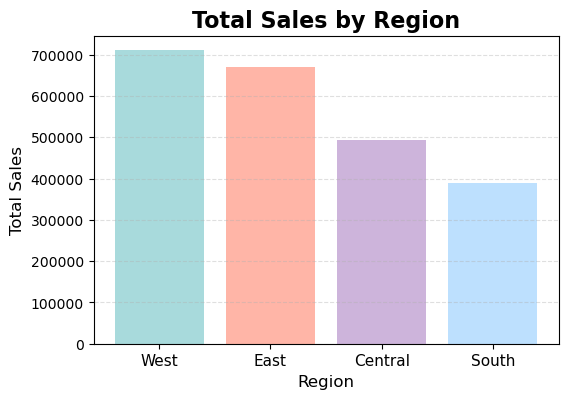

In [25]:
plt.figure(figsize=(6, 4))
plt.bar(
    sales_by_region.index,
    sales_by_region.values,
    color=pastel_colors[:len(sales_by_region)]
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Insight: Sales by Region

This chart shows how total sales are distributed across different regions.  
The West region generated the highest total sales, indicating strong business performance in that area.

In [26]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

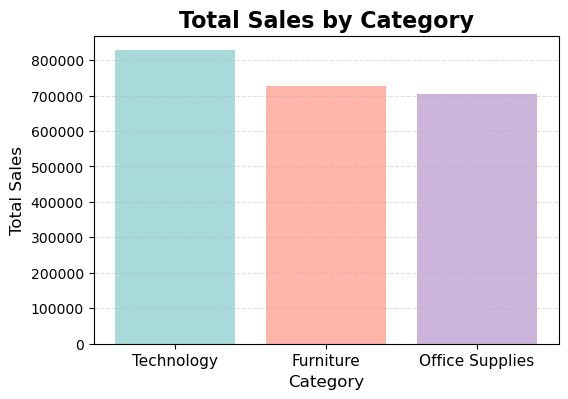

In [27]:
plt.figure(figsize=(6, 4))
plt.bar(
    sales_by_category.index,
    sales_by_category.values,
    color=pastel_colors[:len(sales_by_category)]
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Insight: Sales by Category

This chart compares total sales across product categories.  
It helps identify which product category contributes the most to overall revenue.

In [28]:
sales_by_year = df.groupby("Order_Year")["Sales"].sum()

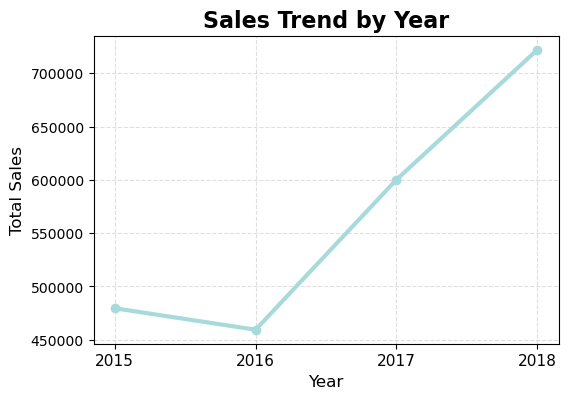

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker="o",
    linewidth=3,
    color="#A8DADC"
)

plt.title("Sales Trend by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(sales_by_year.index, fontsize=11)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### Insight: Sales Trend by Year

The yearly sales trend helps evaluate whether sales performance is increasing or decreasing over time.

In [30]:
sales_by_month = df.groupby("Order_Month")["Sales"].sum()

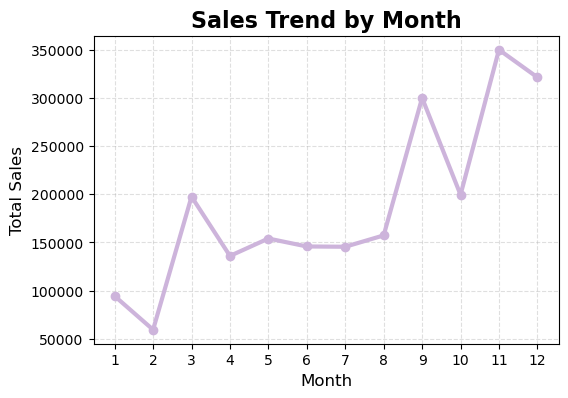

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(
    sales_by_month.index,
    sales_by_month.values,
    marker="o",
    linewidth=3,
    color="#CDB4DB"
)

plt.title("Sales Trend by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(range(1, 13), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### Insight: Sales Trend by Month

The monthly sales trend helps identify seasonal patterns and months with higher customer demand.

-------------------------------------------
## 8. Machine Learning Analysis

In this section, two machine learning techniques are applied:

1. Classification: to predict shipping status.
2. Clustering: to group orders based on sales and shipping behavior.

These models are used to add a predictive and pattern-discovery layer to the business analysis.

--------------------------------------------------------------------------------------------
### 1. Classification: Predicting Shipping Status
The goal of this model is to predict whether an order will be classified as Fast, Normal, or Late Shipping based on selected order features.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [33]:
features = ["Sales","Order_Year","Order_Month","Ship_Mode","Region","Segment","Category"]

X = df[features]
y = df["Shipping_Status"]

X = pd.get_dummies(X, drop_first=True)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
classification_model = DecisionTreeClassifier(random_state=42)

classification_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
y_pred = classification_model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 2))

Accuracy: 0.81


### Classification Result

The classification model achieved an accuracy of 81%.

This means the model correctly predicted the shipping status for 81% of the test records.  
The improvement in accuracy indicates that the selected features helped the model better understand shipping patterns.

However, accuracy alone is not enough to fully evaluate the model, so the classification report was also used to review the performance for each shipping category.

In [38]:
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

  Fast Shipping       0.88      0.86      0.87       608
  Late Shipping       0.16      0.17      0.17       126
Normal Shipping       0.85      0.85      0.85      1226

       accuracy                           0.81      1960
      macro avg       0.63      0.63      0.63      1960
   weighted avg       0.81      0.81      0.81      1960



The classification report provides more detailed evaluation metrics such as precision, recall, and F1-score for each shipping category.  
This helps identify whether the model performs equally well across Fast, Normal, and Late Shipping classes.

---------------------------------------------------------
### 2. Clustering: Grouping Orders Based on Behavior
The goal of clustering is to group orders with similar behavior based on sales amount, shipping duration, and order month.

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
cluster_data = df[["Sales", "Shipping_Days", "Order_Month"]]

In [41]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(cluster_scaled)

In [43]:
cluster_summary = df.groupby("Cluster")[["Sales", "Shipping_Days", "Order_Month"]].mean()

cluster_summary

,Sales,Shipping_Days,Order_Month
Cluster,,,
0,235.172637,4.852955,10.309581
1,248.466337,1.550173,8.426471
2,212.706428,4.517776,4.216348


### Clustering Interpretation

The clustering model grouped the orders into three clusters based on Sales, Shipping Days, and Order Month.

- **Cluster 0**: This group has an average sales value of **235.17** and the highest average shipping duration of **4.85 days**. It mostly represents orders placed later in the year, around month **10**.

- **Cluster 1**: This group has the highest average sales value of **248.46** and the shortest average shipping duration of **1.55 days**. This cluster represents higher-value orders with faster shipping performance.

- **Cluster 2**: This group has the lowest average sales value of **212.71** and an average shipping duration of **4.52 days**. It mostly represents orders placed earlier in the year, around month **4**.

Overall, Cluster 1 appears to be the strongest operational group because it combines higher sales with faster shipping. Cluster 0 and Cluster 2 may require more attention due to longer average shipping durations.

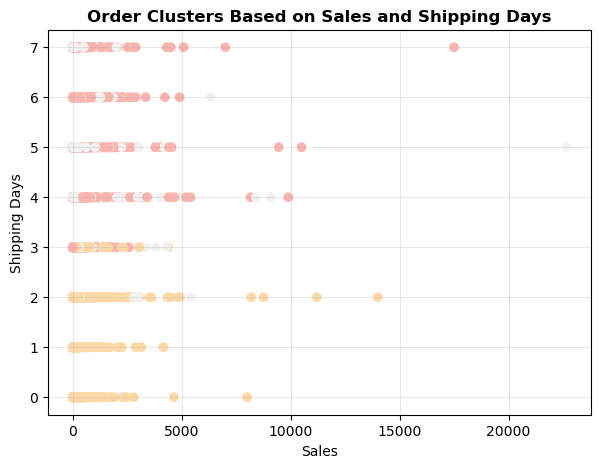

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Sales"],
    df["Shipping_Days"],
    c=df["Cluster"],
    cmap="Pastel1"
)

plt.title("Order Clusters Based on Sales and Shipping Days", fontsize=12, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Shipping Days")
plt.grid(alpha=0.3)
plt.show()

The scatter plot visualizes the order clusters based on Sales and Shipping Days.  
Each color represents a different cluster identified by the KMeans algorithm.

## 9. Export Cleaned Dataset

The cleaned and processed dataset is exported for further use in Power BI dashboard development.

In [45]:
df.to_csv("Superstore_Sales_Cleaned.csv", index=False)